<a href="https://colab.research.google.com/github/Dan-nisimi/Machine-Learning-ADVANCE-SCRIPTS/blob/main/Model_Tunning_and_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCTION TO HYPERPARAMETER TUNNING

In [ ]:
#Parameters and Hyperparameters

#Parameters are values learned by a machine learning model during training and used for prediction.They are adjusted to minimize the error of the model on the training data
# but not on the test data. That is ti minimize loss function and optimize predictions. Examples are co-efficient in linear regression and weight and biases in neural network.

#Hyperparameters are values that are not learned by the model and are set by the user before training which settings then defines and influence how the model learns from data.
#Examples are learning rate, tree depth, number of estimators and batch size in gradient descent. They are not learned from the data but insteead controls the training process.



 1. **Simple Layman Language:**
In machine learning, *parameters* are like knobs or settings inside the model that get adjusted automatically during training to make the model better at its task. For example, if the model is trying to recognize cats in pictures, these parameters are fine-tuned to decide what makes something look like a cat (whiskers, ears, etc.).

*Hyperparameters*, on the other hand, are like settings outside the model that you, the user, choose before training. These settings control how the model learns. For example, you can decide how long the model will learn (training time) or how fast it will learn (learning rate).

**Example:**
Imagine baking a cake:
- *Parameters* are like the ingredients (flour, sugar, eggs)—they change and adjust during the baking process.
- *Hyperparameters* are like the oven temperature and baking time—you set these before starting, and they affect how the cake turns out.

---
 2. **Like You’re 5 Years Old:**
Let’s say you’re trying to teach your toy robot how to spot your favorite color, red.

- The robot’s *parameters* are like its eyes—while practicing, it figures out what “red” looks like (a little lighter than brown, but not pink). Its eyes keep getting better at spotting red as it practices.
- The *hyperparameters* are what you decide beforehand—like how many times your robot gets to practice or how quickly it learns. It’s kind of like the rules of the game you choose before the robot starts.

**Example:**
It’s like coloring a picture:
- *Parameters* are the colors the picture ends up using (red, blue, yellow—they change as you color).
- *Hyperparameters* are the size of your crayons or the time you spend coloring (you decide this first).


In [ ]:
# Importance of Tunning Hyperparameters
# Hyperparameter Tuning is a process of finding the best combination of hyperparameters that optimize the performance of a machine learning model.

#Tunning improves model efficiency, accuracy and reduces overfitting.
#Ehance efficiency: Proper tunning can reduce training time and computational resources
#Adapt to problem needs: Tailoring hyperparameters can ensures the model fit the dataset chacracteristics

#Common Hyperparameters in Popular Models
#1. Decision Trees and Random Forest
# - Max depth: Limits the depth of the tree to avoid overfitting
# - Min samples split: Minimum number of samples required to split a node
# - Number of estimators: Total Number of trees to build in random forest

#2. Gradient Boosting models
# - Learning rate: Controls the learning rate of the model and determines the contribution of each tree to the final prediction
# - Subsmaple: Subsample fraction of the training data used to build each tree
# - Max depth: Limits the depth or complexity of the individual tree to avoid overfitting

#4. Neural Networks
# - Leaarning rate: Controls the step size or weight updates of the network
# -Number of layers: Determine the network depth
# - Batch size: Controls the number of training examples processed in each iteration of the training process or number of samples by gradient update


In [ ]:
#Exercise: Train a model with default hyperparameters, evaluate its performance, and manually adjust a few hypeperparameters to observe their impact on results

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset info
print(f"Feature Names: {data.feature_names}")
print(f"Class Names: {data.target_names}")

# Train Random Forest with default hyperparameters
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Predict and evaluate
y_predict_default = rf_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_predict_default)

print(f"Default Model Accuracy: {accuracy_default:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_predict_default))

# Train Random Forest with adjusted hyperparameters
rf_tuned = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

# Predict and evaluate
y_pred_tuned = rf_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print("\n Classification Report:\n", classification_report(y_test, y_pred_tuned))

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Class Names: ['malignant' 'benign']
Default Model Accuracy: 0.9649

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Tuned Model

#GRID SEARCH AND RANDOM SEARCH

In [ ]:
#Grid search?
# Grid search is a hyperparameter tuning technique that exhaustively searches over a predefined range of hyperparameter values to find the best combination that maximizes the model performance.

#How it works?
#1. Define a range of hyperparameters to search over
#2. Evaluate the model performance for each combination of hyperparameters
#3. Select the combination that maximizes the model performance

#Random Search?
# Random search is a hyperparameter tuning technique that randomly samples hyperparameter values from a predefined range and evaluates the model performance for each sample.

#How does it work?
#1. Define a range or distribution of hyperparameters to search over
#2. Generate a random sample of hyperparameter values combination
#3. Evaluate the model performance for each sample
#4. Select the sample that maximizes the model performance

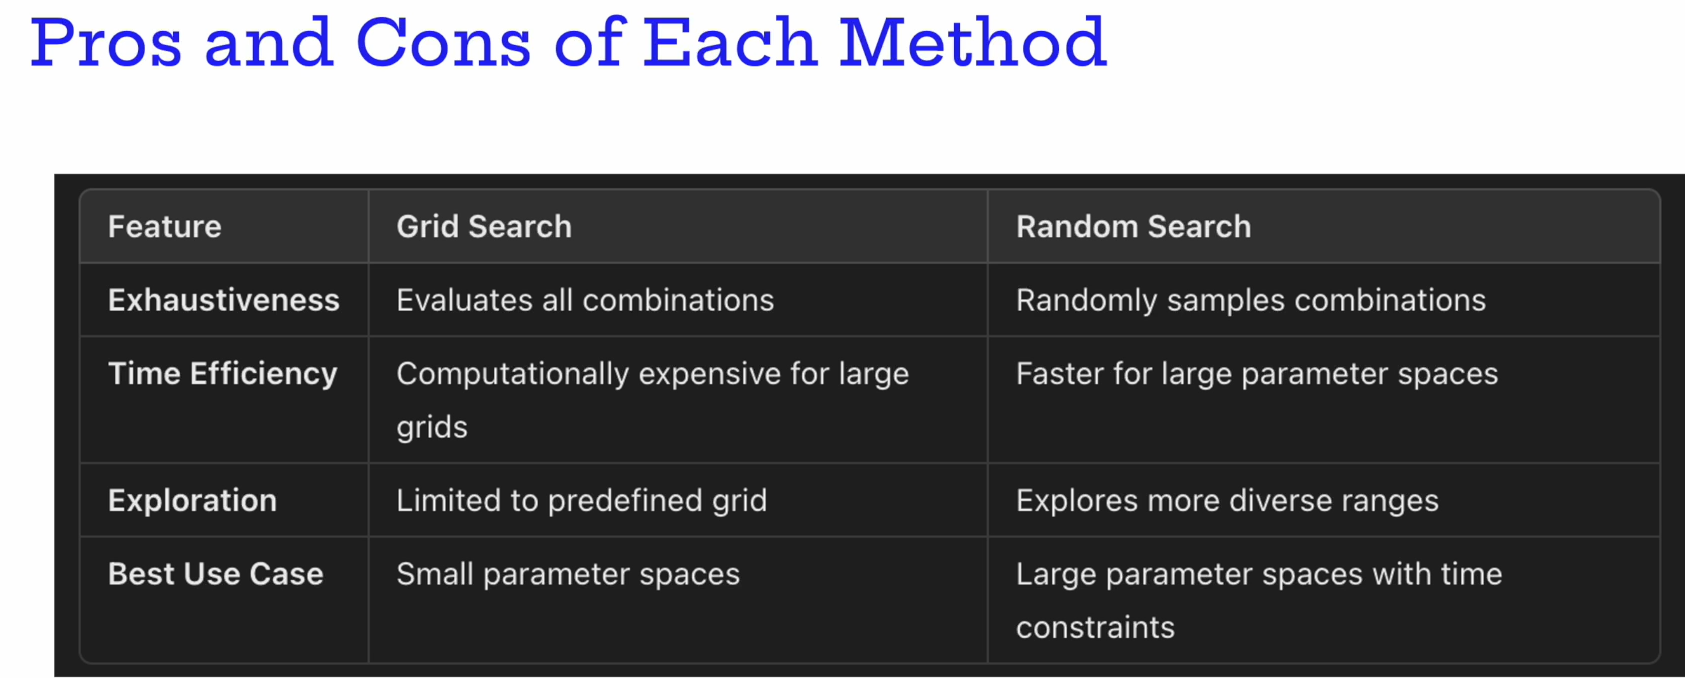

In [ ]:
#Practical Guidelines on Choosing Search Ranges

#- Start with Broad Ranges: Start with a broad range of hyperparameters and narrow down the search space as you progress.
# - Refine with Grid Search: Narrow search space based on random search results and perform exhaustive grid search for fine tuning.
# - Understand Model Sensitivity: Some hyperparameters e.g learning rate require fine granularity(e.g. 0.1, 0.01, 0.001) while others (e.g number of trees) are more coarse-grained(e.g. 10, 100, 1000).

In [ ]:
#Exercise: Implement both Grid Search and Random Search for hyperparameter tunning, compare their efficiency, and analyze the impact on Model performance

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset info
print(f"Feature Names: {data.feature_names}") #data.feature_names is a list of feature names from the dataset loaded using the load_iris() function from scikit-learn library
print(f"Class Names: {data.target_names}")

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 #-1 means use all available CPU cores
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Evaluate best model
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)

print(f"Best Hyperparameters (Grid Search): {grid_search.best_params_}")
print(f"Grid Search Accuracy: {accuracy_grid:.4f}")

# Define hyperparameter distribution
param_dist = {
    'n_estimators': np.arange(50, 200, 10),
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 20]
}

# Initialize Random Search
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist, #param_dist is a dictionary specifying the range of values for each hyperparameter to be sampled
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Perform Random Search
random_search.fit(X_train, y_train)#X_train is a numpy array containing the training features and y_train is a numpy array containing the training labels

# Evaluate best model
best_random_model = random_search.best_estimator_ #best_random_model is a RandomForestClassifier object representing the best model found by the RandomizedSearchCV
y_pred_random = best_random_model.predict(X_test) #y_pred_random is a numpy array containing the predicted class labels for the test set X_test using the best_random_model
accuracy_random = accuracy_score(y_test, y_pred_random) #accuracy_random is a float representing the accuracy of the best_random_model on the test set X_test
#accuracy_score(y_test, y_pred_random) is a function from scikit-learn library that computes the accuracy of a classifier on a given dataset

print(f"Best Hyperparameters (Random Search): {random_search.best_params_}")
print(f"Random Search Accuracy: {accuracy_random:.4f}")

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class Names: ['setosa' 'versicolor' 'virginica']
Best Hyperparameters (Grid Search): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Grid Search Accuracy: 1.0000
Best Hyperparameters (Random Search): {'n_estimators': np.int64(140), 'min_samples_split': 5, 'max_depth': None}
Random Search Accuracy: 1.0000


# ADVANCE HYPERPARAMATER TUNNING WITH BAYESIAN OPTIMIZATION

In [ ]:
#Bayesian optimization can be defined as a technique used to optimize a machine learning model by iteratively searching for the best hyperparameters value based on the performance of the model on a given dataset.
#It balances exploration (searching new hyperparameter values or region) and exploitation (refinning those promising regions) to find the best hyperparameters value that maximizes the model performance.
#Uses probabilistic model to guide the search for the best hyperparameters value

#How it works
#Surrogate model: Builds a probabilistic (e.g gaussian) model of the performance of a model on a given dataset as a function of the hyperparameters value.
#Acquisition function: Defines a function that guides the search for the best hyperparameters value, typically based on the performance of the model on a given dataset.
#Iterative refinement: Updates the surrogate model after each evaluation, refinning the search space based on the performance of the model on a given dataset.

#Why Use Bayesian Optimization?
#1. Efficient for high-demensional and expensive to evaluate functions
#2. Reduces the number of evaluations required to find the best hyperparameters value

#Using Libraries for Bayesian Optimization
#- BayesOpt: Python library for Bayesian optimization
#- Hyperopt: Simplifies BO for hyperparameter tunning, works with fmin to optimize a function
#- Optuna: Python library for hyperparameter optimization, supports dynamic search space and prunning(means to reduce the search space) of trials
#- Scikit-Optimize: Python library for hyperparameter optimization

#Understanding Exploration vs Exploitation

#Exploration: Search for new hyperparameters value in the search space i.e sampling new hyperparameters value from unexplored region and useful for
#identifying new promising regions or areas of high potential performance

#Exploitation: Refine the search space based on the performance of the model on a given dataset. Useful for tunning near optimal hyperparameters value

#Bayesian Optimization Advantages
#- Efficient for high-dimensional and expensive to evaluate functions
#- Reduces the number of evaluations required to find the best hyperparameters value
#- Supports dynamic search space and prunning(means to reduce the search space) of trials
#- Balances the approaches using the acquisition function to minimize uneccessary evaluations while maximizing the performance of the model on a given dataset and
#improving results in less time

Of course! Here's how Bayesian optimization works, explained step by step:

### 1. **Simple Layman Language**
Bayesian optimization is a method used to find the best settings or solutions for a problem—especially when testing each option directly is slow or expensive. It works by making smart guesses about which options are most likely to be the best, testing them, and then using those results to improve its guesses over time.

**Example:**
Imagine you're trying to find the best recipe for cookies but don't want to bake hundreds of batches. Bayesian optimization would first make an educated guess about the best ingredient amounts, bake that batch, taste it, and then use the feedback to make even better guesses for the next batch. It keeps guessing smarter until you get perfect cookies.

---

### 2. **Like You’re 5 Years Old:**
Let’s say you’re playing a game where you want to find the yummiest ice cream flavor in the shop. You don’t want to taste all the flavors because that would take forever (and give you a tummy ache).

- So, you start by trying one flavor that looks good. Then you ask, “Was that close to the best flavor?” The game helps you guess another flavor based on what it learned from your first try. You keep playing smarter and smarter until you find the yummiest one.

**Example:**
It’s like picking a toy from a big pile of presents:
- Bayesian optimization helps you guess which present is most fun to open based on what you learn from the first few toys.


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 18.3 MB/s eta 0:00:00


In [ ]:
#EX: Apply Bayesian Optimization using Optuna to tune an XGBoost model and compare the results with Grid Search and Random Search

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import optuna


# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# SPlit into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training data shape: {X_train.shape}")#xtrain.shape is a tuple containing the number of samples and features in the training set
print(f"Test data shape: {X_test.shape}")

# Train a baseline XGBoost model
baseline_model = XGBClassifier(eval_metric='logloss', random_state=42)
baseline_model.fit(X_train, y_train)

# Evaluate the model
baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)
print(f"Baseline XGBoost Accuracy: {baseline_accuracy:.4f}")

# Define the objective function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10)
    }
#subsample is a hyperparameter that controls the fraction of data to be used for each tree
#colsample_bytree is a hyperparameter that controls the fraction of features to be used for each tree
#gamma is a hyperparameter that controls the complexity of the model
#reg_alpha and reg_lambda are hyperparameters that control the regularization(L1 and L2) of the model

    # Train XGBoost model with suggested params
    #**params is a dictionary containing the hyperparameters and their suggested values
    model = XGBClassifier(eval_metric='logloss', random_state=42, **params)
    model.fit(X_train, y_train)

    # Evaluate model on validation set
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# Create an Optuna study

#optuna.create_study() is a function from optuna library that creates a new study object
#maximize is a parameter that specifies that the study should optimize the objective function for maximization
#study.optimize(objective, n_trials=50) is a function from optuna library that optimizes the objective function for 50 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Best hyperparameters
print("Best Hyperparameters:", study.best_params)
print("Best Accuracy: ", study.best_value)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

# Train XGBoost with Grid Search
grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss',random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1 # verbosity level means how much information to print during the search process
)
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("\n\n\nGrid Search Best Parameters: ", grid_search.best_params_)
print("Grid Search Best Accuracy:", grid_search.best_score_)

# Define parameter distributions
param_dist = {
    'n_estimators': [50,100,200,300,400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Train XGBoost with Random Search
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

# Best parameters and accuracy
print("\n\n\nRandom Search Best Parameters:", random_search.best_params_)
print("Random Search Best Accuracy:", random_search.best_score_)


# Baseline XGBoost Accuracy: 0.9561
# Optuna Best Accuracy:  0.9649122807017544
# Grid Search Best Accuracy: 0.9757900546067155
# Random Search Best Accuracy: 0.9758045776693388

[I 2025-04-16 21:04:37,512] A new study created in memory with name: no-name-cba43039-6398-4cd0-a954-849fbff026bf
[I 2025-04-16 21:04:37,613] Trial 0 finished with value: 0.956140350877193 and parameters: {'n_estimators': 235, 'max_depth': 84, 'learning_rate': 0.17511408191838695, 'subsample': 0.9512707600961546, 'colsample_bytree': 0.8031938268422469, 'gamma': 2.1807375867664343, 'reg_alpha': 1.1274521499081558, 'reg_lambda': 4.170227269089148}. Best is trial 0 with value: 0.956140350877193.


Training data shape: (455, 30)
Test data shape: (114, 30)
Baseline XGBoost Accuracy: 0.9561


[I 2025-04-16 21:04:37,712] Trial 1 finished with value: 0.9649122807017544 and parameters: {'n_estimators': 244, 'max_depth': 96, 'learning_rate': 0.15974010549858772, 'subsample': 0.8674140459790698, 'colsample_bytree': 0.8089693563643341, 'gamma': 4.121237725846808, 'reg_alpha': 5.119836451587246, 'reg_lambda': 0.6841126587917434}. Best is trial 1 with value: 0.9649122807017544.
[I 2025-04-16 21:04:37,844] Trial 2 finished with value: 0.956140350877193 and parameters: {'n_estimators': 332, 'max_depth': 40, 'learning_rate': 0.2774374895472031, 'subsample': 0.7703600833595436, 'colsample_bytree': 0.7731787238448087, 'gamma': 2.690228058033533, 'reg_alpha': 6.631084131496426, 'reg_lambda': 3.4543399058481397}. Best is trial 1 with value: 0.9649122807017544.
[I 2025-04-16 21:04:37,952] Trial 3 finished with value: 0.956140350877193 and parameters: {'n_estimators': 219, 'max_depth': 94, 'learning_rate': 0.2980630320428648, 'subsample': 0.9228520141566735, 'colsample_bytree': 0.7029646147

Best Hyperparameters: {'n_estimators': 244, 'max_depth': 96, 'learning_rate': 0.15974010549858772, 'subsample': 0.8674140459790698, 'colsample_bytree': 0.8089693563643341, 'gamma': 4.121237725846808, 'reg_alpha': 5.119836451587246, 'reg_lambda': 0.6841126587917434}
Best Accuracy:  0.9649122807017544
Fitting 3 folds for each of 81 candidates, totalling 243 fits



Grid Search Best Parameters:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6}
Grid Search Best Accuracy: 0.9757900546067155
Fitting 3 folds for each of 50 candidates, totalling 150 fits



Random Search Best Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Random Search Best Accuracy: 0.9735970721505751


# REGULARIZATION TECHNIQUES FOR MODEL OPTIMIZATION

In [ ]:
#Understanding Overfitting and Underfitting

#Overfitting: When a model learns the noise on the training data alongside the patterns leading to poor performance on the test (unseen) data
#This leads to high training accuracy but low test accuracy. Also, large differences between training and validation losses

#Underfitting: When a model fails to capture the underlying patterns in the data because it is too simple, leading to low training and test accuracy.
# Also, large differences between training and validation losses and high bias in predictions

#Regularization Techniques
#Regularization is a technique used to prevent overfitting by adding a penalty term to the loss function and discouraging complex models.

#L1 Regularization (Lasso): Adds absolute value penalty to the model coefficients, leading to sparse models and reduced complexity
#L2 Regularization (Ridge): Adds squared value penalty to the model coefficients, leading to smaller coefficients (but doesn't set them to zero) and reduced complexity
#Elastic Net: Combines L1 and L2 regularization, leading to a balance between sparsity and reduced complexity. It is useful when there are correlated predictors
#and when feature selection is desired.

#Practical Application of Regularization Techniques
#- Prevent overfitting by adding a penalty term to the loss function and discouraging complex models
#- Improve model interpretability by reducing the complexity of the model
#- Improve generalization by reducing the bias in predictions
# - Handle multicolinearity and reduce the impact of highly correlated features (especially in L2 regularization)
# - Feature slection: Lasso automatically selects features that are most important for the task and can be used to reduce the model complexity and improve generalization


### 1. **Simple Layman Language:**
Regularization techniques are like a safety feature for machine learning models that prevents them from getting overly complicated or "overfitted"—where the model becomes so perfect at training data that it forgets how to work well with new data.

- **L1 Regularization (Lasso):** L1 makes the model simpler by encouraging it to ignore less important features (turn them to zero). Imagine packing for a trip and you decide to leave behind things you don't really need to lighten your luggage.

- **L2 Regularization (Ridge):** L2 keeps all the features but gently shrinks the impact of less important ones. It’s like spreading the weight evenly so no feature becomes overly important. Imagine packing lighter versions of every item instead of leaving anything behind.

**Example:**
Say you're trying to predict the price of a house using features like its size, location, number of rooms, etc.
- L1 (Lasso) might decide that "number of rooms" isn’t very important and drop it altogether.
- L2 (Ridge) might still keep "number of rooms" but make its influence smaller.

---

### 2. **Like You’re 5 Years Old:**
Let’s pretend you have a magic backpack. The backpack has lots of pockets, but it’s too heavy to carry, so you need to make it lighter.

- With **L1 Regularization (Lasso)**, you take out some pockets completely and leave them behind to make your backpack super light.
- With **L2 Regularization (Ridge)**, you don’t remove any pockets, but you make all the pockets smaller so the backpack isn’t as heavy.

**Example:**
You’re trying to carry toys to play in the park.
- L1 (Lasso) might say, “Let’s just take the car toy and leave behind the rocket toy—it’s too big and not really needed.”
- L2 (Ridge) might say, “Let’s make both the car and the rocket toy smaller so everything fits.”



In [ ]:
#Ex: Apply L1 and L2 regularization techniques on a linear regression model, compare the performance, and analyze the effects on co-efficients

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Load dataset
california = fetch_california_housing()
X, y = california.data, california.target
feature_names = california.feature_names

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset info
print("Feature Names:\n", feature_names)
print("\n Sample Data:\n", pd.DataFrame(X, columns=feature_names).head())

# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred)

print(f"Linear Regression MSE (No Regularization): {mse_lr:.4f}")
print("Coefficients:\n", lr_model.coef_)

# Train Ridge regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse_ridge:.4f}")
print("Coefficients:\n", ridge_model.coef_)

# Train Lasso regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Lasso Regression MSE: {mse_lasso:.4f}")
print("Coefficients:\n", lasso_model.coef_)

Feature Names:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Sample Data:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Linear Regression MSE (No Regularization): 0.5559
Coefficients:
 [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Ridge Regression MSE: 0.5559
Coefficients:
 [ 4.48658477e-01  9.72442833e-03 -1.23292361e-01  7.82971747e-01
 -2.02924019e-06 

#CROSS VALIDATION AND MODEL EVALUATION TECHNIQUES

In [ ]:
# Cross validation is a statistical technique used to evaluate the performance
# of a machine learning model on unseen data.
#It does this by splitting the available training and validation data into multiple subsets
#and then evaluating the model on each subset.
# It helps ensures that the model is not overfitting the training data and can
# generalize well to unseen data.

#Why use CV
#Prevents overfitting: By evaluating the model on multiple subsets of the data, cv helps provide a more robust estimate of the model's performance
#It reduces the variance of the model's predictions and prevents it from overfitting to the training data compared to a single train/test split
#It optimizes model selection: Helps in comparing and selecting the best model among multiple models that are trained on different subsets of the data

#Types of CV

#- K-fold cross validation: Divides the data into k subsets and uses k-1 subsets for training and 1 subset for validation
#It does this by:
#- Randomly shuffling the data
#- Dividing the data into k equal subsets
#- Using k-1 subsets for training and 1 subset for validation
#- Repeating this process k times, ensuring that each subset is used as the validation set once
# -Best for general purpose datasets

#Stratified K-fold Cross Validation: Same as K-fold cross validation but ensures that each subset has the same distribution of classes as the entire or original dataset
#It does this by:
#Ensuring that each subset has the same distribution of classes as the entire or original dataset
#-Best for imbalanced datasets e.g Classification problems with imbalanced classes or datasets

#Leave-one-out cross validation: Divides the data into n subsets and uses n-1 subsets for training and 1 subset for validation
#It does this by:
#- Randomly shuffling the data
#- Using a single subset for validation and the rest for training
#Pros: Maximises training data usage for each fold
#Cons: Can be computationally expensive for large datasets
#-Best for small datasets

#Practical Guidance on Cross-Validation
#- Select the appropriate type of cross-validation based on the characteristics of your dataset and the model you are training
#- Choose K based on the size of the dataset and the desired level of accuracy e.g K = 5 or 10 for large datasets, LOOCV for small datasets
# - Stratification for imbalanced datasets: Always prefer K-fold CV when dealing with imbalanced datasets to ensure fair evaluation
#- Combine with hyperparameter tuning to find the best model and hyperparameters: Integrate CV into Grid or Random Search for robust hyperparameter tunning

In [ ]:
#Ex: 1. Evaluate a classification model using K-fold and stratified K-fold cross validation
    # 2. Compare the results to demonstrate the importance of stratification for
# imbalanced datasets

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier


# Load Dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Display dataset info
print("Dataset Info:\n")
print(df.info)
print("\n Class Distribution:\n")
print(df['Class'].value_counts())

# Define Features and target
#df.drop means drop the column Class from the dataset
X = df.drop(columns=['Class'])
y = df['Class'] #target variable

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate model
rf_model = RandomForestClassifier(random_state=42)
scores_kfold = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"K-fold cross validation scores: {scores_kfold}")
print(f"Mean Accuracy (K-Fold): {scores_kfold.mean():.2f}")

# initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate model
scores_stratified = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Stratified K-fold cross validation scores: {scores_stratified}")
print(f"Mean Accuracy (Stratified K-Fold): {scores_stratified.mean():.2f}")

Dataset Info:

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462

# AUTOMATED HYPERPARAMETER TUNNING WITH GRIDSEARCHCV AND RANDOMIZED SEARCHCV

In [ ]:
#GridsearchCV is a hyperparameter tuning technique used to find the optimal hyperparameters for a machine learning model
#It does this by iterating over a grid of hyperparameter values and evaluating the model on each combination of hyperparameters using CV.

#RandomsearchCV is a hyperparameter tuning technique used to find the optimal hyperparameters for a machine learning model
#It does this by randomly sampling a grid of hyperparameter values and evaluating the model on each combination of hyperparameters using CV.
#It is faster than gridsearcg for large hyperparameter spaces while still providing good results.

#Using Both in Scikit-Learn
#- Automates the process of hyperparameter tuning: combines model training, evaluation and hyperparameter search into a single step
# - Cross validation integration: Ensures robust performance metrics by using cross validation to evaluate the model on multiple subsets of the data
# - Results interpretation: Provides the best hyperparameter combination and associated metrics for the model

#Integrating CV with hyperparameter tunning
#CV ensures that hyperparameters selected generalize well to unseen data. Benefits include:
#Reduces overfitting to the training dataset
#Provides robust estimate of model performance

#Interpreting results and selecting best model
#Best paramters: Access the optimal hyperparameter combination using the .best_params_ attribute
#Best estimator: Access the model trained with the best hyperparameters using the .best_estimator_ attribute
#Best score: Access the performance metric of the best hyperparameters using the .best_score_ attribute


### 1. **Simple Layman Language:**
Both `GridSearchCV` and `RandomizedSearchCV` are methods used to find the best combination of hyperparameters (settings) for a machine learning model. Think of them as ways to test different settings to figure out what works best.

- **GridSearchCV:** This method tries every possible combination of the hyperparameters you provide. It's thorough and ensures you find the absolute best option, but it can take a long time if there are lots of settings to test.
- **RandomizedSearchCV:** Instead of trying every single combination, this method picks a random sample of the combinations. It’s faster and works well when you don’t have time to test everything.

**Example:**
Imagine you’re trying to find the best outfit to wear from a closet full of clothes:
- GridSearchCV would try on every possible combination of tops, bottoms, and accessories to find the best outfit—no skipping!
- RandomizedSearchCV would randomly pick outfits to try on without testing every single combination. It’s quicker but might miss some options.

---

### 2. **Like You’re 5 Years Old:**
Let’s say you’re playing a game where you want to pick the best toy from a big toy box.

- **GridSearchCV** is like trying out *every single toy* in the box to see which one is the most fun. It takes forever, but you’re sure to find the best toy.
- **RandomizedSearchCV** is like reaching into the box and testing just a few random toys. It’s faster, and you still might find a really fun toy—but you won’t try all of them.

**Example:**
It’s like searching for the yummiest candy in a bag:
- GridSearchCV would taste *every candy* to find the best one.
- RandomizedSearchCV would taste just a handful of random candies and hope to find a good one faster.

In [1]:
#EX: Use GridsearchCV and RandomizedsearchCV to tune hyperparameters
#of Gradient Boosting model and Support Vector Machine models and compare the results

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
import numpy as np


# Load dataset
data = load_iris()
X, y = data.data, data.target

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset Loaded and Split Successfully")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Get best parameters and score
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

print(f"Best Parameters (GridSeachCV): {best_params_grid}")
print(f"Best Cross-Validation Accuracy (GridSearchCV): {best_score_grid:.4f}")

# Get best model
best_grid_model = grid_search.best_estimator_ #best estimator is the model trained with the best hyperparameters

# Predict and evaluate with best model
y_pred_grid = best_grid_model.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)

print(f"Test Accuracy (GridSearchCV): {accuracy_grid:.4f}")
print("\n Classification Report:\n", classification_report(y_test, y_pred_grid))

# Define parameter distribution
param_dist = {
    'C': np.logspace(-3, 3, 10), # Logarithmic distribution from 0.001 to 1000 with 10 values
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initalize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Perform Randomized Search
random_search.fit(X_train, y_train)

# Get best parameters and score
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print(f"Best Parameters (RandomizedSearchCV): {best_params_random}")
print(f"Bestr Cross-Validation Accuracy (RandomizedSearchCV): {best_score_random:.4f}")

# Get best model
best_random_model = random_search.best_estimator_

# Predict and evaluate
y_pred_random = best_random_model.predict(X_test)
accuracy_random = accuracy_score(y_test, y_pred_random)

print(f"Test Accuracy (RandomizedSeachCV): {accuracy_random:.4f}")
print("\n Classsification Report:\n", classification_report(y_test, y_pred_random))





Dataset Loaded and Split Successfully
Best Parameters (GridSeachCV): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation Accuracy (GridSearchCV): 0.9500
Test Accuracy (GridSearchCV): 1.0000

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Best Parameters (RandomizedSearchCV): {'kernel': 'poly', 'gamma': 'auto', 'C': np.float64(0.021544346900318832)}
Bestr Cross-Validation Accuracy (RandomizedSearchCV): 0.9583
Test Accuracy (RandomizedSeachCV): 0.9667

 Classsification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.

# OPTIMIZATION PROJECT: BUILDING AND TUNNING A FINAL MODEL

In [ ]:
#Applying all learned tunning and optimization techniques

#Comprehensive Model Optimization
# - Data Preprocessing: Ensure data is clean, scaled and encoded properly
# - Feature engineering: Create new features that improve model performance and select the most relevant ones
# - Regularization: Use regularization techniques to prevent overfitting and improve model generalization by penalizing complex models
# - Cross-validation: Use cross-validation techniques like kfold or stratified kfold to evaluate the model on multiple subsets of the data and ensure robust performance metrics
# - Hyperparameter tuning: Use hyperparameter tuning techniques like gridsearch or randomizedsearch or bayesian optimization to find the best hyperparameters for the model

#Evaluating and Interpreting Model Performance

#Performance metrics

# - Classification metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC

#- Regression metrics: R2, MAE, MSE, RMSE

#- Clustering metrics: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index

# - Importance of interpretability: feature importance, co-efficient of analysis for transparency


In [1]:
#Create an upload button
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [4]:
 # Load dataset
 import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")

The primary problem this dataset aims to solve is customer churn prediction.

What is Customer Churn?

Customer churn, also known as customer attrition, refers to the rate at which customers stop doing business with a company or service. In the context of the Telco Customer Churn dataset, this means customers discontinuing their telecommunications services (phone, internet, etc.).

Why is it important?

Revenue Loss: Losing customers directly impacts a company's revenue and profitability.
Increased Acquisition Costs: Acquiring new customers is typically more expensive than retaining existing ones.
Brand Damage: High churn rates can negatively affect a company's reputation.
How does the dataset address it?

The dataset contains information about various customer demographics, service usage, and account details. This information can be used to build predictive models that identify customers who are at high risk of churning. By understanding the factors driving churn, companies can take proactive steps to retain these customers.

In Summary:

The Telco Customer Churn dataset is used to solve the business problem of predicting and preventing customer churn. By using the data to build predictive models, telco companies can identify at-risk customers and implement strategies to retain them, reducing revenue loss, and improving customer satisfaction.

### 1. **Simple Layman Language:**
Both `min_samples_leaf` and `min_samples_split` are settings used in decision tree models to control how the tree grows. They help avoid overfitting, which happens when the model becomes too specific and performs poorly on new data.

- **min_samples_leaf:** This is the minimum number of data points (samples) required to form a leaf node. A leaf node is the end point of a branch in a decision tree that makes the final decision. By setting this, you ensure that no leaf is created with too few samples, making the model more general.
- **min_samples_split:** This is the minimum number of data points required to split a node into further branches. If a node doesn’t meet this requirement, it won’t split, keeping the tree simpler.

**Example:**
Imagine you’re cutting a tree down to the right shape:
- `min_samples_leaf` is like saying, "Each branch must have at least 3 fruits—otherwise, it’s too small to keep."
- `min_samples_split` is like saying, "Only branches with at least 5 fruits can be cut further into smaller branches."

---

### 2. **Like You’re 5 Years Old:**
Let’s pretend you’re building a tower with toy blocks!

- **min_samples_leaf:** This means every stack at the bottom of the tower (the base) has to have at least 3 blocks. Otherwise, the stack is too tiny to keep—it might fall over.
- **min_samples_split:** This means every layer of the tower has to have at least 5 blocks before you’re allowed to split it into smaller stacks for the next layer.

**Example:**
You’re building a treehouse:
- `min_samples_leaf` might say, “Every branch of your treehouse must have at least 2 planks to stand on.”
- `min_samples_split` might say, “Only branches strong enough to hold 3 planks can split into more branches for your treehouse.”

In [7]:
#Project: Build, tune and optimize a machine learning model using a structured process and evaluate its performance comprehensively

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

 # Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display dataset info
print("Dataset Info:\n")
print(df.info())
print("\n Class Distribution: \n")
print(df['Churn'].value_counts())
print("\n Sample Data:\n", df.head())

# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #errors='coerce' converts non-numeric values to NaN
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True) #inplace=True updates the original dataframe

# Encode categorical variables

label_encoder = LabelEncoder()
#include=['object'] specifies that only object data type columns should be encoded
for column in df.select_dtypes(include=['object']).columns:
#if the column is not 'Churn' then encode it
    if column != 'Churn':
        df[column] = label_encoder.fit_transform(df[column])

# Encode target (outcome or dependent) variable
df['Churn'] = label_encoder.fit_transform(df['Churn'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Features and Target
X = df.drop(columns=['Churn'])
y = df['Churn']

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train initial model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# EValuate inital model
y_pred = rf_model.predict(X_test)
accuracy_initial = accuracy_score(y_test, y_pred)

print(f"Initial Model Accuracy: {accuracy_initial:.4f}")
print("\n Classification Report: \n", classification_report(y_test, y_pred))

# Define parameter grid
#min_samples_split=2 is the minimum number of samples required to split a node
#min_samples_leaf=1 is the minimum number of samples required to be at a leaf node
param_dist = {
    'n_estimators': np.arange(50, 200, 10),
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Initialze RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Perform Randomized Search
random_search.fit(X_train, y_train)

# Get best parameters
best_params = random_search.best_params_
print(f"Best Parameters (RandomizedSearchCV): {best_params}")

# Train best model
best_model = random_search.best_estimator_

# Predict and Evaluate
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Tunes Model Accuracy: {accuracy_tuned:.4f}")
print("\n Classification Report (Tuned Model):\n", classification_report(y_test, y_pred_tuned))

# Evaluate using cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-